# Fase 2 — EDA: Air Quality (UCI)

Integrante: Federico Rodríguez Franco

## Carga y limpieza
Limpia el marcador `-200` y arma el índice temporal.

In [1]:
# En Google Colab, descomenta para subir el archivo:
# from google.colab import files
# files.upload()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

CANDIDATOS = [
    "../data/AirQualityUCI.csv",
    "data/AirQualityUCI.csv",
    "AirQualityUCI.csv",
]
RUTA = next((p for p in CANDIDATOS if os.path.exists(p)), "AirQualityUCI.csv")
print("Archivo de datos:", RUTA)

df = pd.read_csv(RUTA, sep=";", decimal=",")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df = df.replace(-200, np.nan)
df["Time"] = df["Time"].str.replace(".", ":", regex=False)
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df = df.set_index("datetime").drop(columns=["Date", "Time"])

print("Forma:", df.shape)
print("Rango:", df.index.min(), "->", df.index.max())
df.describe().T.round(2)

Archivo de datos: ../data/AirQualityUCI.csv
Forma: (9471, 13)
Rango: 2004-03-10 18:00:00 -> 2005-04-04 14:00:00


,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.15,1.45,0.10,1.10,1.8,2.90,11.90
PT08.S1(CO),8991.0,1099.83,217.08,647.00,937.00,1063.0,1231.00,2040.00
NMHC(GT),914.0,218.81,204.46,7.00,67.00,150.0,297.00,1189.00
C6H6(GT),8991.0,10.08,7.45,0.10,4.40,8.2,14.00,63.70
PT08.S2(NMHC),8991.0,939.15,266.83,383.00,734.50,909.0,1116.00,2214.00
NOx(GT),7718.0,246.90,212.98,2.00,98.00,180.0,326.00,1479.00
PT08.S3(NOx),8991.0,835.49,256.82,322.00,658.00,806.0,969.50,2683.00
NO2(GT),7715.0,113.09,48.37,2.00,78.00,109.0,142.00,340.00
PT08.S4(NO2),8991.0,1456.26,346.21,551.00,1227.00,1463.0,1674.00,2775.00
PT08.S5(O3),8991.0,1022.91,398.48,221.00,731.50,963.0,1273.50,2523.00


## Valores faltantes

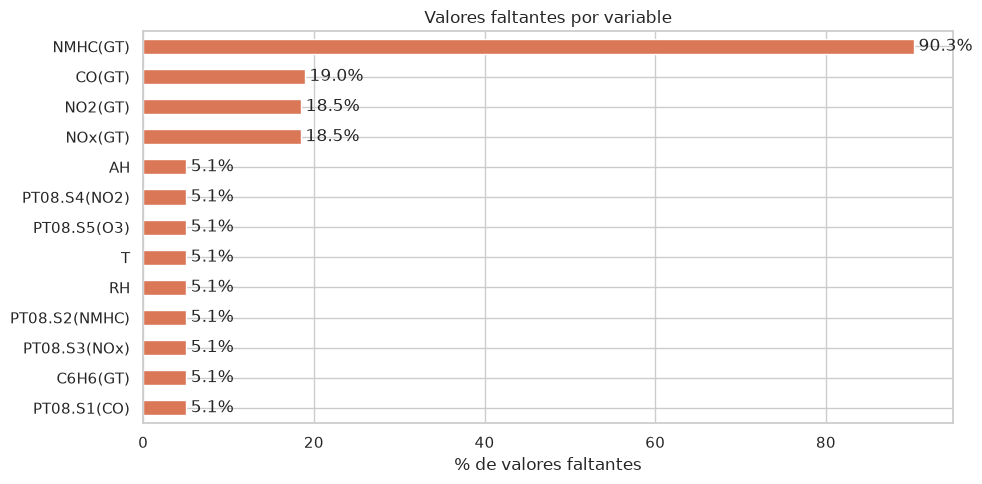

,% faltante
PT08.S1(CO),5.1
C6H6(GT),5.1
PT08.S3(NOx),5.1
PT08.S2(NMHC),5.1
RH,5.1
T,5.1
PT08.S5(O3),5.1
PT08.S4(NO2),5.1
AH,5.1
NOx(GT),18.5


In [2]:
faltantes = (df.isna().mean() * 100)
faltantes = faltantes[faltantes > 0].sort_values(ascending=True)

ax = faltantes.plot.barh(color="#d97757")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Valores faltantes por variable")
for i, v in enumerate(faltantes):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

faltantes.to_frame("% faltante").round(1)

## Valores atípicos
Boxplots, IQR y z-score.

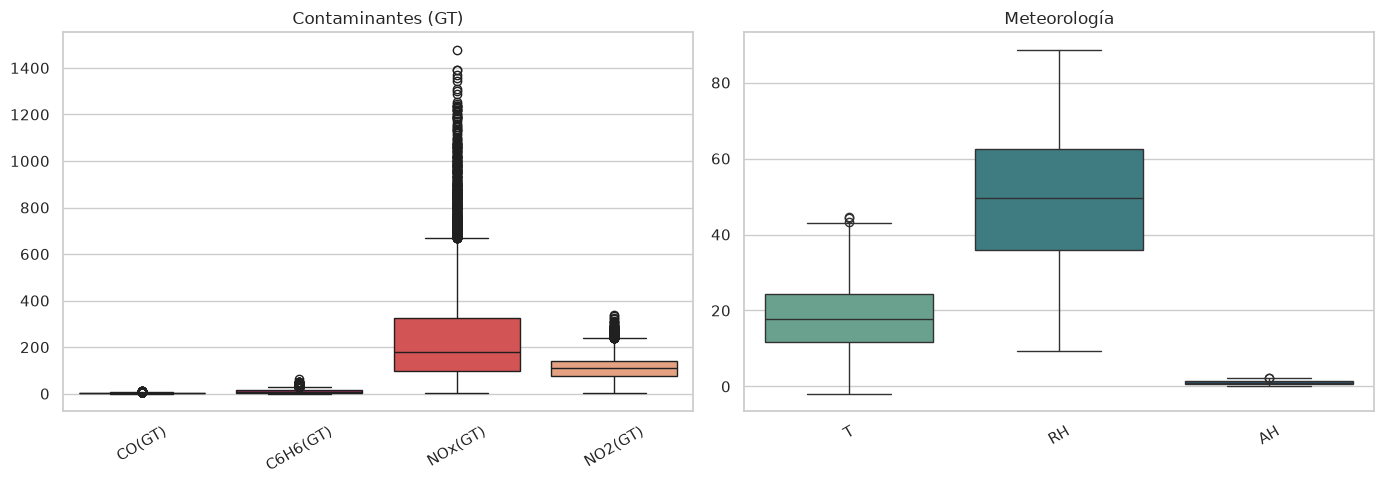

In [3]:
cols_gt = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
cols_meteo = ["T", "RH", "AH"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[cols_gt], ax=axes[0], palette="rocket")
axes[0].set_title("Contaminantes (GT)")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=df[cols_meteo], ax=axes[1], palette="crest")
axes[1].set_title("Meteorología")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [4]:
def resumen_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()
    z = (s - s.mean()) / s.std()
    n_z = (z.abs() > 3).sum()
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "outliers IQR": n_iqr, "% IQR": round(100 * n_iqr / s.notna().sum(), 1),
        "outliers z>3": n_z,
    })

resumen = pd.DataFrame({c: resumen_outliers(df[c]) for c in cols_gt + cols_meteo}).T
resumen.round(2)

,Q1,Q3,IQR,outliers IQR,% IQR,outliers z>3
CO(GT),1.10,2.90,1.80,215.0,2.8,102.0
C6H6(GT),4.40,14.00,9.60,228.0,2.5,118.0
NOx(GT),98.00,326.00,228.00,435.0,5.6,138.0
NO2(GT),78.00,142.00,64.00,107.0,1.4,48.0
T,11.80,24.40,12.60,3.0,0.0,0.0
RH,35.80,62.50,26.70,0.0,0.0,0.0
AH,0.74,1.31,0.58,2.0,0.0,0.0


## Distribuciones

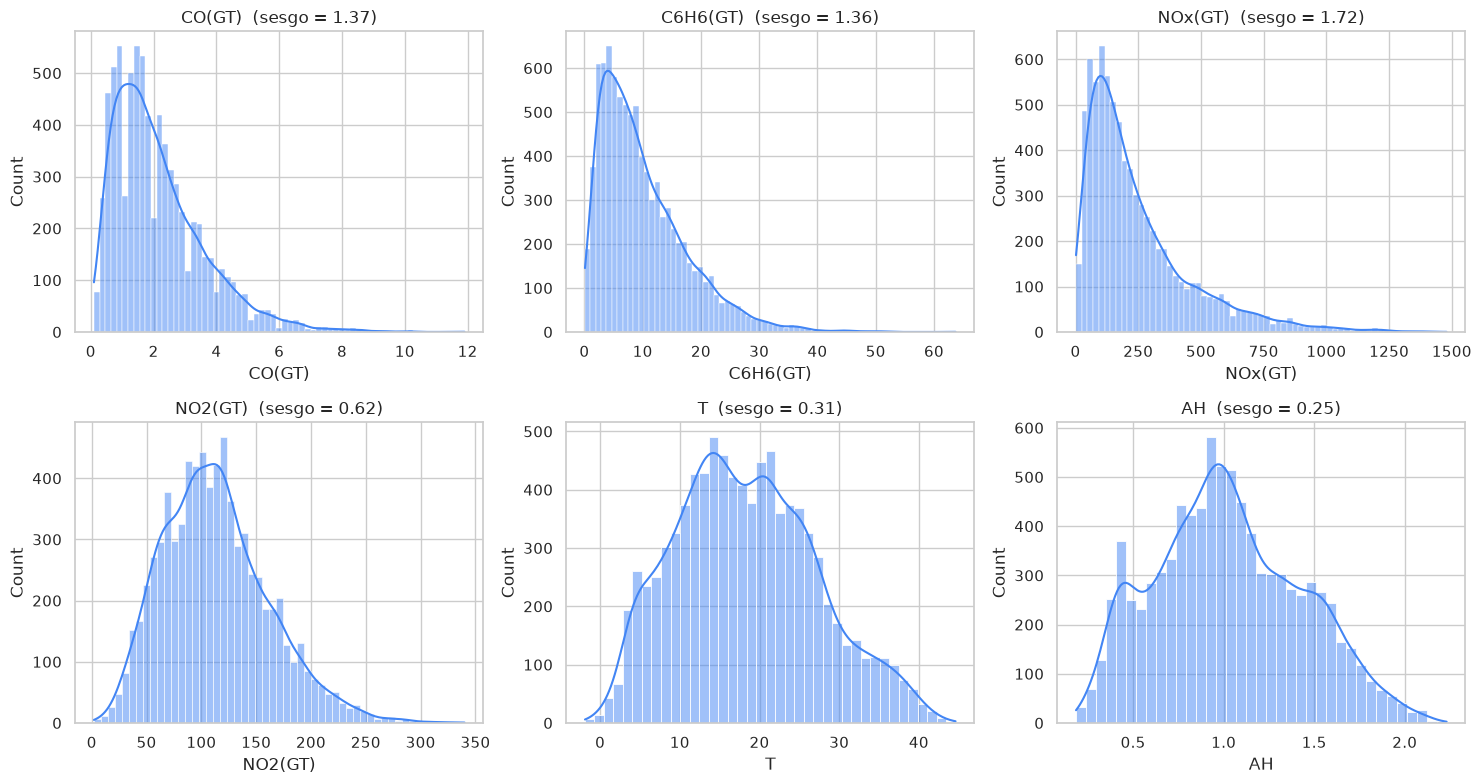

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, cols_gt + ["T", "AH"]):
    sns.histplot(df[c], kde=True, ax=ax, color="#4285f4")
    ax.set_title(f"{c}  (sesgo = {df[c].skew():.2f})")
plt.tight_layout()
plt.show()

In [6]:
df[cols_gt + cols_meteo].skew().sort_values(ascending=False).round(2)

NOx(GT)     1.72
CO(GT)      1.37
C6H6(GT)    1.36
NO2(GT)     0.62
T           0.31
AH          0.25
RH         -0.04
dtype: float64

## Univariado

/tmp/ipykernel_127965/1533643295.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(dias)


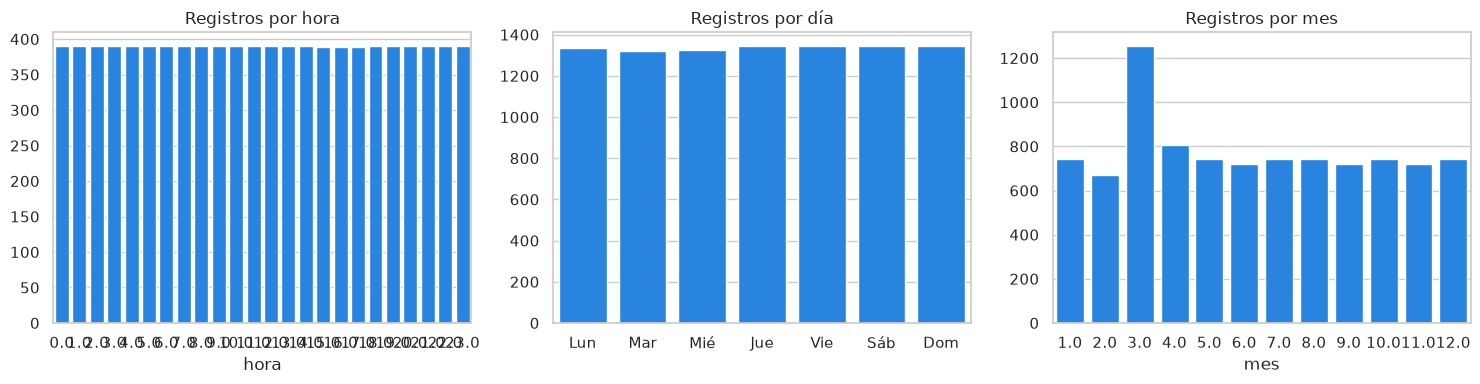

In [7]:
df["hora"] = df.index.hour
df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x=df["hora"].value_counts().sort_index().index,
            y=df["hora"].value_counts().sort_index().values, ax=axes[0], color="#0a84ff")
axes[0].set_title("Registros por hora")
sns.barplot(x=list(range(7)), y=df["dia_semana"].value_counts().sort_index().values,
            ax=axes[1], color="#0a84ff")
axes[1].set_xticklabels(dias)
axes[1].set_title("Registros por día")
sns.barplot(x=df["mes"].value_counts().sort_index().index,
            y=df["mes"].value_counts().sort_index().values, ax=axes[2], color="#0a84ff")
axes[2].set_title("Registros por mes")
plt.tight_layout()
plt.show()

## Multivariado

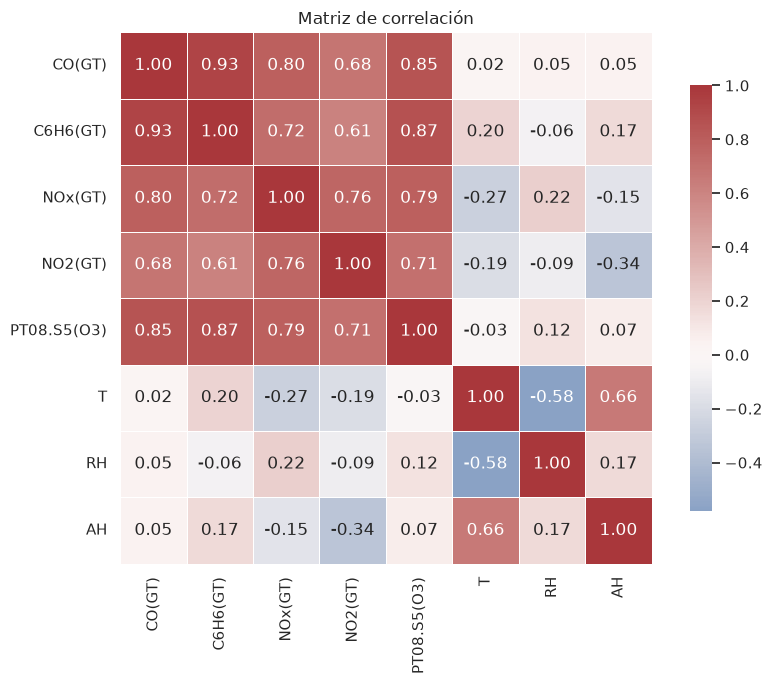

In [8]:
subset = df[["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "PT08.S5(O3)", "T", "RH", "AH"]]
corr = subset.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

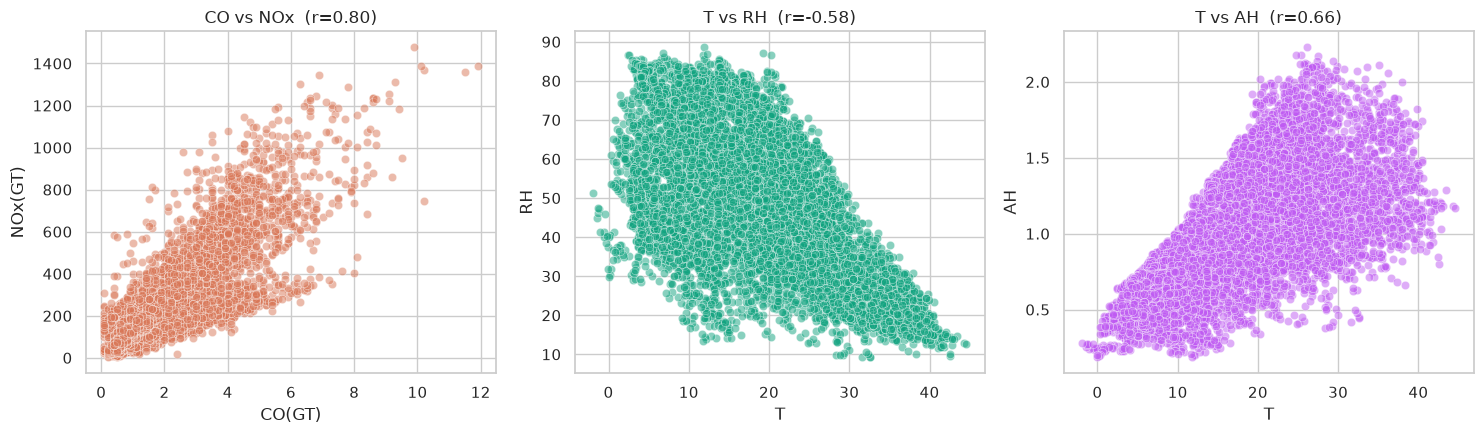

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(data=df, x="CO(GT)", y="NOx(GT)", ax=axes[0], color="#d97757", alpha=.5)
axes[0].set_title(f"CO vs NOx  (r={df['CO(GT)'].corr(df['NOx(GT)']):.2f})")
sns.scatterplot(data=df, x="T", y="RH", ax=axes[1], color="#10a37f", alpha=.5)
axes[1].set_title(f"T vs RH  (r={df['T'].corr(df['RH']):.2f})")
sns.scatterplot(data=df, x="T", y="AH", ax=axes[2], color="#bf5af2", alpha=.5)
axes[2].set_title(f"T vs AH  (r={df['T'].corr(df['AH']):.2f})")
plt.tight_layout()
plt.show()

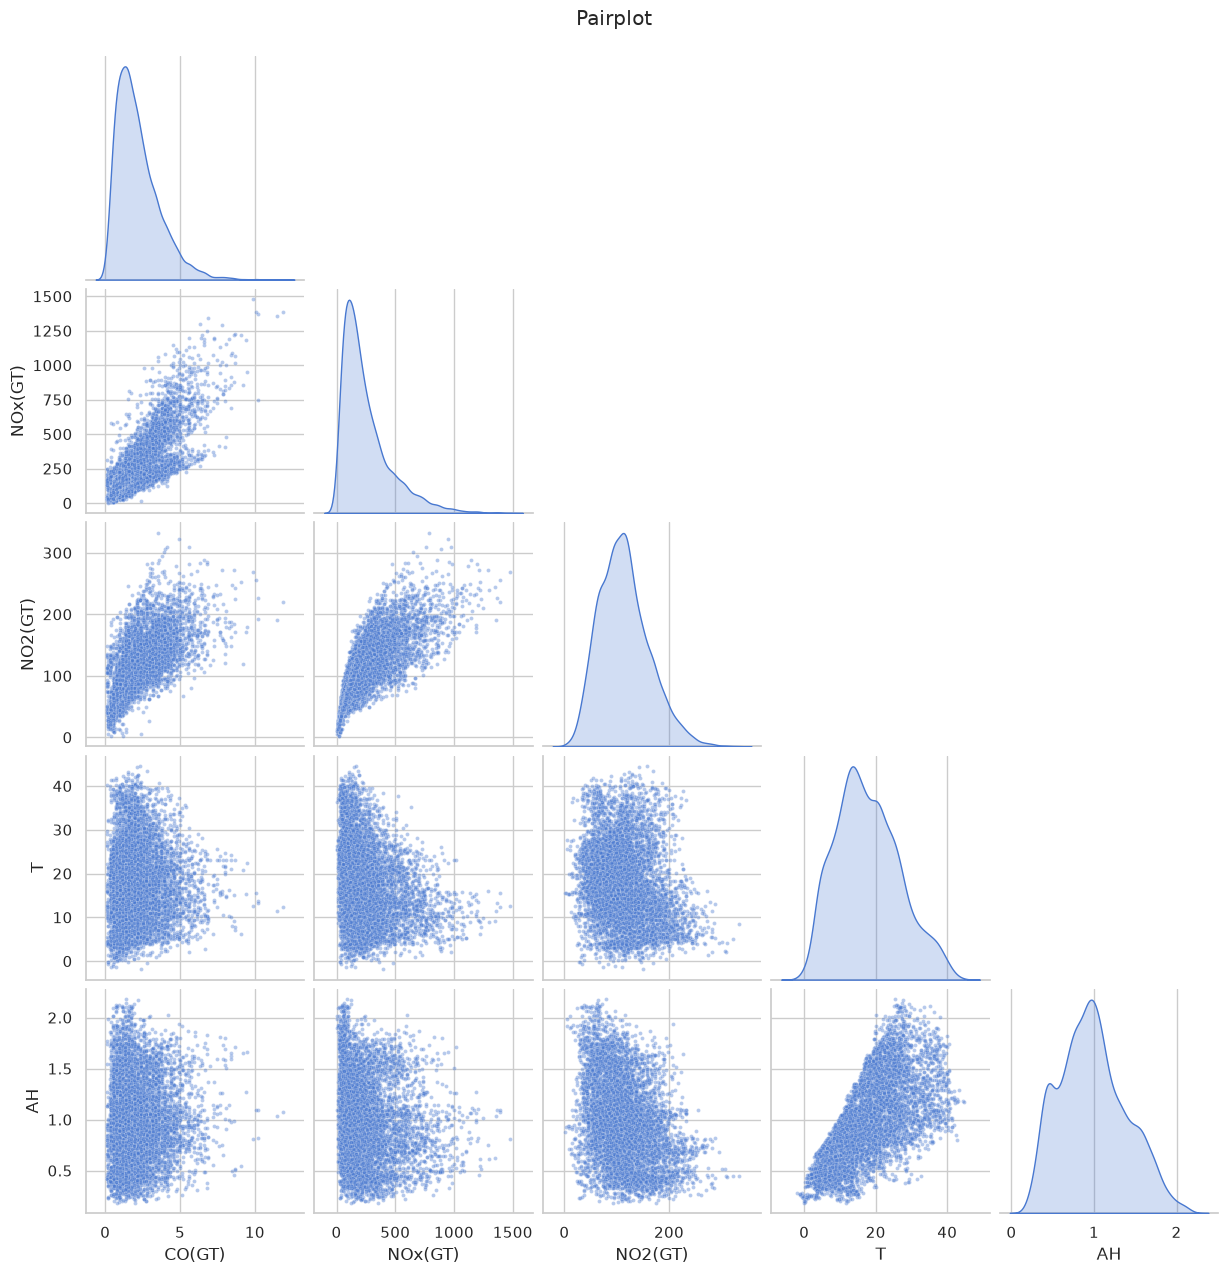

In [10]:
g = sns.pairplot(df[["CO(GT)", "NOx(GT)", "NO2(GT)", "T", "AH"]].dropna(),
                  diag_kind="kde", corner=True, plot_kws={"s": 8, "alpha": .4})
g.fig.suptitle("Pairplot", y=1.02)
plt.show()

## Series de tiempo

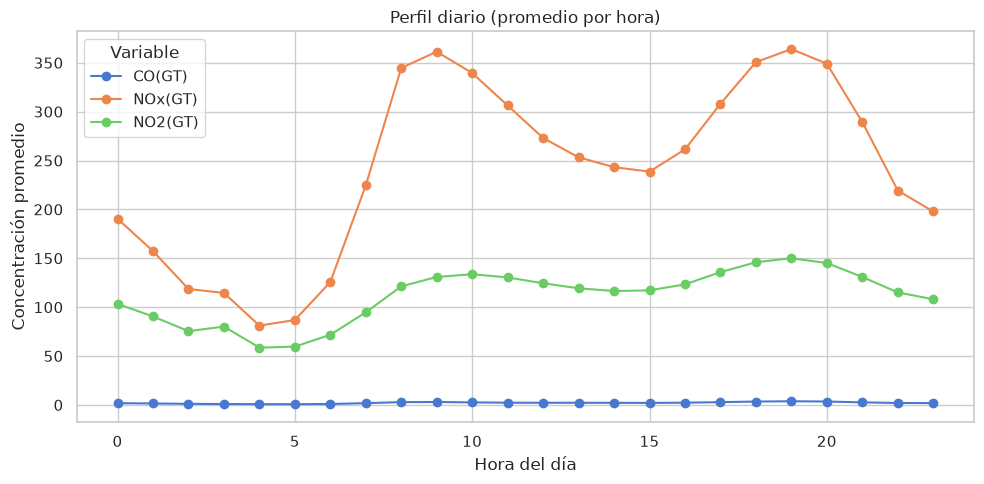

In [11]:
perfil = df.groupby("hora")[["CO(GT)", "NOx(GT)", "NO2(GT)"]].mean()
perfil.plot(marker="o")
plt.title("Perfil diario (promedio por hora)")
plt.xlabel("Hora del día")
plt.ylabel("Concentración promedio")
plt.legend(title="Variable")
plt.tight_layout()
plt.show()

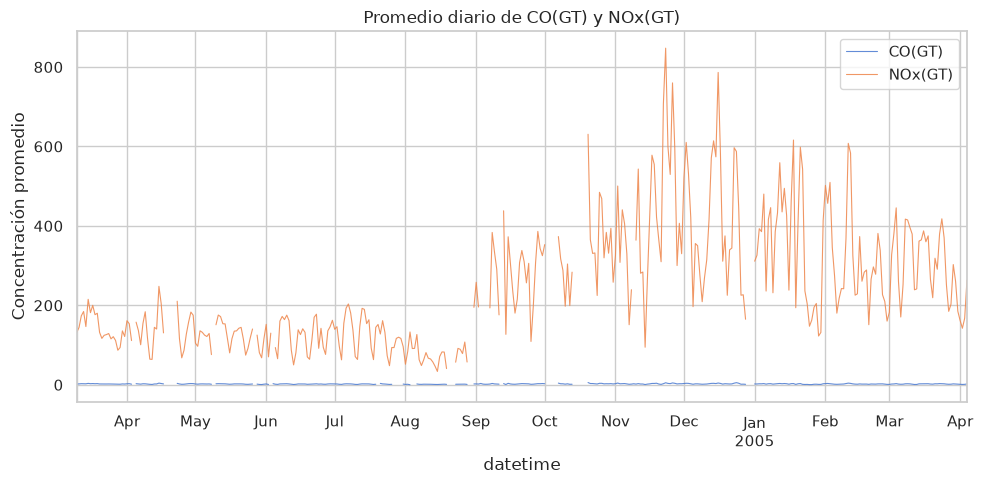

In [12]:
diario = df[["CO(GT)", "NOx(GT)"]].resample("D").mean()
diario.plot(alpha=.85, linewidth=.8)
plt.title("Promedio diario de CO(GT) y NOx(GT)")
plt.ylabel("Concentración promedio")
plt.tight_layout()
plt.show()

/tmp/ipykernel_127965/4103485474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mes", y="CO(GT)", palette="rocket")


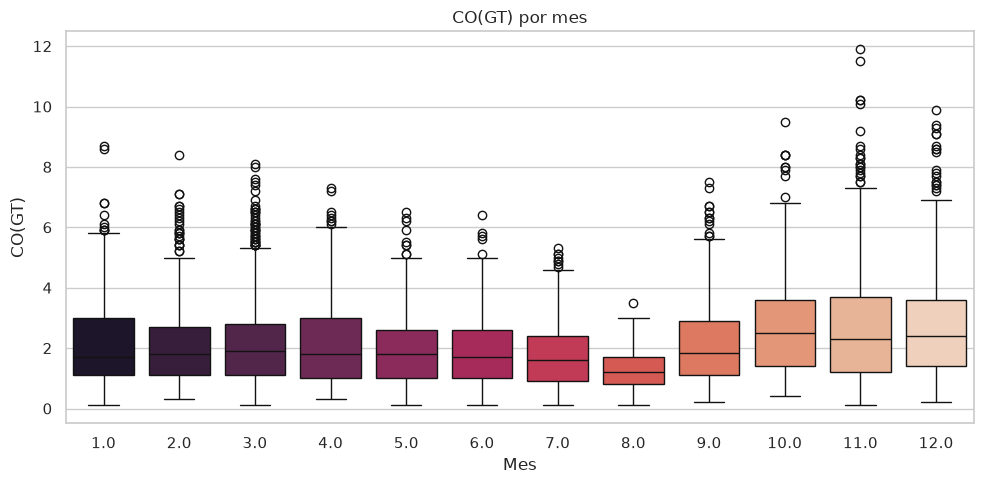

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="mes", y="CO(GT)", palette="rocket")
plt.title("CO(GT) por mes")
plt.xlabel("Mes")
plt.tight_layout()
plt.show()

## Hipótesis
1. La contaminación es mayor en horas pico (7–9 h y 18–20 h).
2. Los niveles son más altos en invierno que en verano.
3. La temperatura se relaciona negativamente con NOx y NO2.
4. CO, C6H6 y NOx comparten un factor subyacente común (tráfico) → una sola componente en PCA.
5. La humedad relativa modula el O3 (fotoquímica).

## Insights
1. Un año completo de datos horarios con dos grupos: contaminantes y meteorología.
2. `NMHC(GT)` irrecuperable (90% faltante); `CO/NOx/NO2` ~18%; el resto ~5%.
3. Correlaciones altas entre contaminantes (hasta 0.93) → variables redundantes.
4. Contaminantes con sesgo positivo fuerte.
5. Picos de contaminación en horas de tráfico y en invierno.
6. Temperatura y humedad correlacionan de forma opuesta con distintos contaminantes.